## Load and Explore the Dataset

In this step, we will perform initial exploratory data analysis (EDA) to gain an understanding of the dataset. This will help us in the future to build pipelines and models more efficiently.

Let's start by importing the libraries that will be used in the future.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Import sklearn usefull libraries as well.

In [52]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
from sklearn import set_config
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

set_config(transform_output="pandas")

Now, let's load the dataset we will be working with, which has been initialized in the repository.

In [3]:
df = pd.read_csv('./data/train.csv')

Next explore some properties of the data.

In [4]:
df.shape

(1460, 81)

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Proceed by checking for missing values in the dataset and sorting them by the number of missing entries.

In [7]:
missing_counts = df.isna().mean()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print('SalePrice' in missing_counts)
missing_counts

False


PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageType      0.055479
GarageYrBlt     0.055479
GarageFinish    0.055479
GarageQual      0.055479
GarageCond      0.055479
BsmtExposure    0.026027
BsmtFinType2    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
dtype: float64

At this stage, let's separate the target variable from the features.

In [8]:
target_col = 'SalePrice'
X = df.drop(columns=[target_col])
y = df[target_col]

For a more effective analysis, separate the columns into categorical and numerical groups

In [9]:
cat_cols = [col for col in X.columns if X[col].dtype == 'object']
num_cols = [col for col in X.columns if X[col].dtype != 'object']

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical columns (37): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageC

At this point, let's create some visualizations.

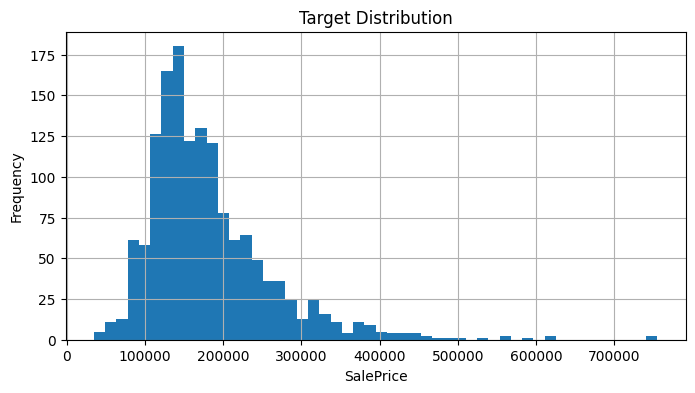

In [10]:
y.hist(bins=50, figsize=(8, 4))
plt.title("Target Distribution")
plt.xlabel(target_col)
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## Build Preprocessing Pipeline

Remov columns with too many N/A values, as they do not provide sufficient information about the target.

In [11]:
class NAHeavyFeatureRemover(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8):
        self.removed_features = []
        self.threshold = threshold

    def fit(self, X, y=None):
        self.removed_features = X.isna().mean()
        self.removed_features = self.removed_features[self.removed_features > self.threshold].index.tolist()
        return self
        
    def transform(self, X):
        X_transformed = X.drop(columns=self.removed_features)    
        return X_transformed

In [12]:
remover = NAHeavyFeatureRemover()
remover.fit_transform(X, y)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,61,0,0,0,0,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,42,0,0,0,0,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,35,272,0,0,0,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,84,0,0,0,0,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,40,0,0,0,0,0,8,2007,WD,Normal
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,2,2010,WD,Normal
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,60,0,0,0,0,2500,5,2010,WD,Normal
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,0,112,0,0,0,0,4,2010,WD,Normal


In this step, we build a preprocessing pipeline that transforms data before training the model.

We will hendle different features differently. Categorical features are processed based on their cardinality (i.e., the number of unique values): columns with 3 or fewer unique values are one-hot encodedand columns with more than 3 unique values are target encoded using the mean of the target variable.

Numerical features are imputed with their median values. After imputation, they are standardized for consistent scaling.

In [13]:
class CustomCategoricalTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=3):
        self.threshold = threshold
        self.mean_columns = []
        self.ohe_columns = []
        self.mean_target_encodings = {}
        self.ohe_columns_encodings = {}

    def fit(self, X, y):
        cat_cols = [col for col in X.columns if X[col].dtype == 'object']
        s = X[cat_cols].nunique()
        self.mean_columns = list(s[s > self.threshold].index)
        self.ohe_columns = list(s[s <= self.threshold].index)
        
        X_temp = X.copy()
        X_temp[target_col] = y
        for col in self.mean_columns:
            encoding = X_temp.groupby(col)[target_col].mean()
            self.mean_target_encodings[col] = encoding.to_dict()
        
        for col in self.ohe_columns:
            unique_vals = X[col].dropna().unique()
            self.ohe_columns_encodings[col] = [f"{col}_{val}" for val in unique_vals]
        
        return self
        
    def transform(self, X):
        X_transformed = X.copy()
        for col in self.mean_columns:
            X_transformed[col] = X_transformed[col].map(self.mean_target_encodings[col])

        for col in self.ohe_columns:
            dummies = pd.get_dummies(
                X_transformed[col], 
                prefix=col, 
                dummy_na=True, 
                dtype=int
            )
            for expected_col in self.ohe_columns_encodings[col]:
                if expected_col not in dummies.columns:
                    dummies[expected_col] = 0
            dummies = dummies[self.ohe_columns_encodings[col]]
            X_transformed = pd.concat([
                X_transformed.drop(col, axis=1), 
                dummies
            ], axis=1)
            
        return X_transformed

In [14]:
transformer = CustomCategoricalTransformer(threshold=3)
X_transformed = transformer.fit_transform(X, y)
X_transformed

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,Neighborhood,Condition1,...,CentralAir_N,GarageFinish_RFn,GarageFinish_Unf,GarageFinish_Fin,PavedDrive_Y,PavedDrive_N,PavedDrive_P,PoolQC_Ex,PoolQC_Fa,PoolQC_Gd
0,1,60,191004.994787,65.0,8450,164754.818378,180183.746758,176938.047529,197965.773333,184495.492063,...,0,1,0,0,1,0,0,0,0,0
1,2,20,191004.994787,80.0,9600,164754.818378,180183.746758,177934.574468,238772.727273,142475.481481,...,0,1,0,0,1,0,0,0,0,0
2,3,60,191004.994787,68.0,11250,206101.665289,180183.746758,176938.047529,197965.773333,184495.492063,...,0,1,0,0,1,0,0,0,0,0
3,4,70,191004.994787,60.0,9550,206101.665289,180183.746758,181623.425856,210624.725490,184495.492063,...,0,0,1,0,1,0,0,0,0,0
4,5,60,191004.994787,84.0,14260,206101.665289,180183.746758,177934.574468,335295.317073,184495.492063,...,0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,191004.994787,62.0,7917,164754.818378,180183.746758,176938.047529,192854.506329,184495.492063,...,0,1,0,0,1,0,0,0,0,0
1456,1457,20,191004.994787,85.0,13175,164754.818378,180183.746758,176938.047529,189050.068493,184495.492063,...,0,0,1,0,1,0,0,0,0,0
1457,1458,70,191004.994787,66.0,9042,164754.818378,180183.746758,176938.047529,210624.725490,184495.492063,...,0,1,0,0,1,0,0,0,0,0
1458,1459,20,191004.994787,68.0,9717,164754.818378,180183.746758,176938.047529,145847.080000,184495.492063,...,0,0,1,0,1,0,0,0,0,0


Now, for dealing with N/A, we will use the SimpleImputer built-in class in Python. Also, we will scale each number using the StandardScaler class.

In [15]:
pipeline = Pipeline([
    ("heavy_na_columns_remover", NAHeavyFeatureRemover(threshold=0.8)),
    ('categorical_transformer', CustomCategoricalTransformer(threshold=3)),
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])


Now, let's choose the best hyperparameters for our model. To do this, we use GridSearchCV.

In [16]:
param_grid = {
    'heavy_na_columns_remover__threshold': [0.3, 0.5, 0.8],
    'categorical_transformer__threshold': [2, 3, 4, 6, 8],
    'imputer__strategy': ['mean', 'median', 'most_frequent'],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X, y)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
[CV] END categorical_transformer__threshold=2, heavy_na_columns_remover__threshold=0.3, imputer__strategy=mean; total time=   0.3s
[CV] END categorical_transformer__threshold=2, heavy_na_columns_remover__threshold=0.3, imputer__strategy=mean; total time=   0.5s
[CV] END categorical_transformer__threshold=2, heavy_na_columns_remover__threshold=0.3, imputer__strategy=mean; total time=   0.4s
[CV] END categorical_transformer__threshold=2, heavy_na_columns_remover__threshold=0.3, imputer__strategy=mean; total time=   0.5s
[CV] END categorical_transformer__threshold=2, heavy_na_columns_remover__threshold=0.5, imputer__strategy=mean; total time=   0.1s
[CV] END categorical_transformer__threshold=2, heavy_na_columns_remover__threshold=0.3, imputer__strategy=mean; total time=   0.1s
[CV] END categorical_transformer__threshold=2, heavy_na_columns_remover__threshold=0.3, imputer__strategy=median; total time=   0.1s
[CV] END categorica

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('heavy_na_columns_remover',
                                        NAHeavyFeatureRemover()),
                                       ('categorical_transformer',
                                        CustomCategoricalTransformer()),
                                       ('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid={'categorical_transformer__threshold': [2, 3, 4, 6, 8],
                         'heavy_na_columns_remover__threshold': [0.3, 0.5, 0.8],
                         'imputer__strategy': ['mean', 'median',
                                               'most_frequent']},
             scoring='neg_mean_squared_error', verbose=2)

As a result, we see that the following thresholds are optimal:

In [17]:
pipeline = Pipeline([
    ("heavy_na_columns_remover", NAHeavyFeatureRemover(threshold=0.3)),
    ('categorical_transformer', CustomCategoricalTransformer(threshold=4)),
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']
results = cross_validate(pipeline, X, y, cv=kfold, scoring=scoring)
results['test_rmse'] = np.sqrt(-results['test_neg_mean_squared_error'])
results

{'fit_time': array([0.20354915, 0.05682969, 0.26370382, 0.17533803, 0.46727514]),
 'score_time': array([0.06259084, 0.02832174, 0.07764959, 0.041363  , 0.22374415]),
 'test_neg_mean_squared_error': array([-8.84262411e+08, -1.06810555e+09, -2.77850353e+09, -8.72889210e+08,
        -5.27580539e+08]),
 'test_r2': array([0.88471645, 0.84290874, 0.49707268, 0.86098507, 0.89906366]),
 'test_neg_mean_absolute_error': array([-18926.46720065, -19725.90553883, -19967.80914624, -19453.01845208,
        -16709.81626198]),
 'test_rmse': array([29736.55007748, 32681.88413707, 52711.51234324, 29544.69851102,
        22969.12141873])}

As we can see, the MSE is too high. It is more likely due to overfitting. Therefore, we need to remove some features. As a first approach, we will use a correlation filter. Formally, we will filter out highly correlated pairs from the dataset to avoid overfitting.

In [18]:
class CustomCorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.features_to_remove = []

    def fit(self, X, y):
        X_corr = X.copy()
        X_corr[target_col] = y
        corr_matrix = X_corr.corr().abs()
        threshold = self.threshold
        high_corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i + 1, len(corr_matrix.columns)):
                if corr_matrix.iloc[i, j] > threshold:
                    high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

        for feat1, feat2, _ in high_corr_pairs:
            if feat1 == target_col or feat2 == target_col:
                continue
            if abs(X[feat1].corr(y)) < abs(X[feat2].corr(y)):
                self.features_to_remove.append(feat1)
            else:
                self.features_to_remove.append(feat2)

        self.features_to_remove = list(set(self.features_to_remove))
        
        return self
        
    def transform(self, X):
        X_transformed = X.drop(columns=self.features_to_remove)    
        return X_transformed

Now, we will use RFE (Recursive Feature Elimination) as well and try to determine how many features are unnecessary and optimal in this case

In [19]:
pipeline = Pipeline([
    ("heavy_na_columns_remover", NAHeavyFeatureRemover(threshold=0.3)),
    ('categorical_transformer', CustomCategoricalTransformer(threshold=4)),
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler()),
    ('correlation_filter', CustomCorrelationFilter()),
    ('feature_selector', RFE(estimator=LinearRegression())),
    ('model', LinearRegression())
])

param_grid = {
    'imputer__strategy': ['mean', 'median', 'most_frequent'],
    'correlation_filter__threshold': [0.7, 0.8, 0.9],  
    'feature_selector__n_features_to_select': [
        0.1, 0.3, 0.5, 0.7,
        10, 20, 30      
    ]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',  
    refit=True, 
    n_jobs=-1,   
    verbose=2
)
grid_search.fit(X, y)


Fitting 5 folds for each of 63 candidates, totalling 315 fits
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=median; total time=   2.1s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=median; total time=   2.2s[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=median; total time=   2.2s

[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   2.2s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   2.2s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   2.3s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   2.3s
[CV] END correl

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('heavy_na_columns_remover',
                                        NAHeavyFeatureRemover(threshold=0.3)),
                                       ('categorical_transformer',
                                        CustomCategoricalTransformer(threshold=4)),
                                       ('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('correlation_filter',
                                        CustomCorrelationFilter()),
                                       ('feature_selector',
                                        RFE(estimator=LinearRegression())),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid={'correlation_filter__threshold': [0.7, 0.8, 0.9],
                         'feature_selector__n_features_to_select': [0.1, 0.3,
                                                                    0.5, 0.7,
                                                                    10, 20,
                                                                    30],
                         'imputer__strategy': ['mean', 'median',
                                               'most_frequent']},
             scoring='neg_mean_squared_error', verbose=2)

In [20]:
print("Best parameters:", grid_search.best_params_)
print("Best RMSE:", np.sqrt(-grid_search.best_score_))
best_pipeline = grid_search.best_estimator_
print(best_pipeline)

Best parameters: {'correlation_filter__threshold': 0.8, 'feature_selector__n_features_to_select': 10, 'imputer__strategy': 'mean'}
Best RMSE: 33863.69461598431
Pipeline(steps=[('heavy_na_columns_remover',
                 NAHeavyFeatureRemover(threshold=0.3)),
                ('categorical_transformer',
                 CustomCategoricalTransformer(threshold=4)),
                ('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('correlation_filter', CustomCorrelationFilter(threshold=0.8)),
                ('feature_selector',
                 RFE(estimator=LinearRegression(), n_features_to_select=10)),
                ('model', LinearRegression())])


In [21]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']
results = cross_validate(best_pipeline, X, y, cv=kfold, scoring=scoring)
results['test_rmse'] = np.sqrt(-results['test_neg_mean_squared_error'])
results

{'fit_time': array([1.12341237, 1.06693673, 1.09854937, 0.96824121, 1.37169313]),
 'score_time': array([0.02609491, 0.02424836, 0.06514478, 0.02662206, 0.2727716 ]),
 'test_neg_mean_squared_error': array([-1.01635265e+09, -1.05606833e+09, -2.16541518e+09, -8.38903217e+08,
        -6.57009692e+08]),
 'test_r2': array([0.86749551, 0.84467911, 0.60804568, 0.86639763, 0.87430136]),
 'test_neg_mean_absolute_error': array([-19594.04887611, -20884.47121977, -21856.28427085, -19182.13437985,
        -18684.79385555]),
 'test_rmse': array([31880.28620628, 32497.20497736, 46534.02171485, 28963.82600124,
        25632.20028987])}

In [22]:
preprocess = Pipeline([('heavy_na_columns_remover', NAHeavyFeatureRemover(threshold=0.3)),
                ('categorical_transformer', CustomCategoricalTransformer(threshold=4)),
                ('imputer', SimpleImputer()), 
                ('scaler', StandardScaler()),
                ('correlation_filter', CustomCorrelationFilter(threshold=0.8)),
                ('feature_selector', RFE(estimator=LinearRegression(), n_features_to_select=10))])

## Logging the First Experiment

We start by importing DagsHub and MLflow.

In [23]:
import dagshub
dagshub.init(repo_owner='zhorzholianimate', repo_name='House-Prices-Advanced-Regression-Techniques', mlflow=True)

Accessing as zhorzholianimate

Initialized MLflow to track repo "zhorzholianimate/House-Prices-Advanced-Regression-Techniques"

Repository zhorzholianimate/House-Prices-Advanced-Regression-Techniques initialized!

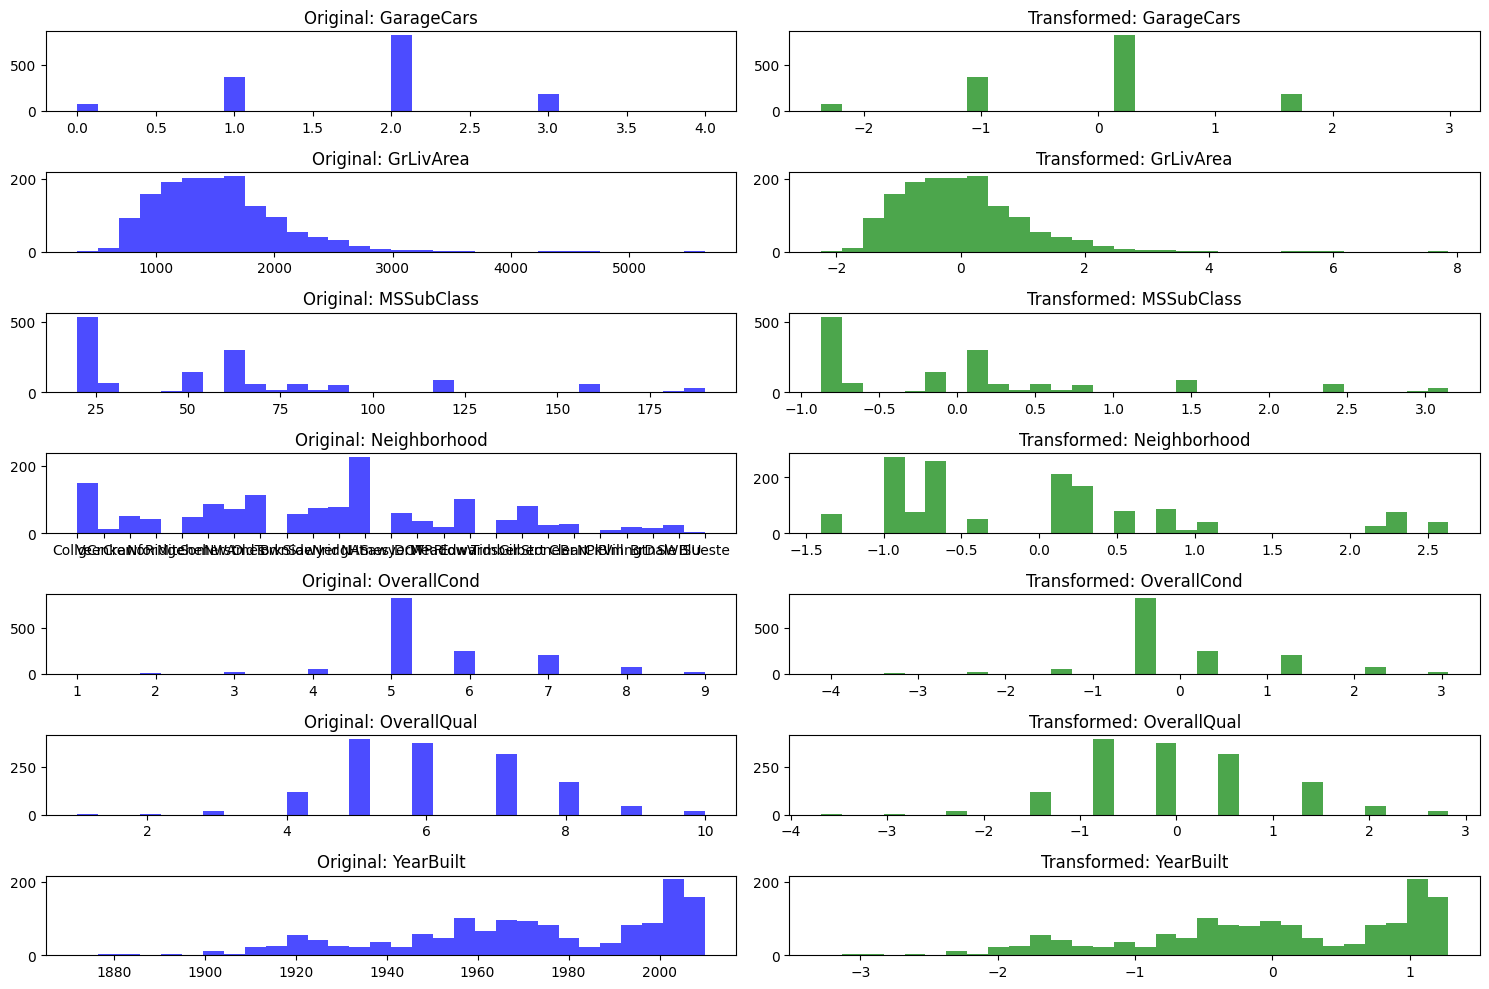

/tmp/ipykernel_74172/2663314314.py:33: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  dummies = pd.get_dummies(
/tmp/ipykernel_74172/2663314314.py:33: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  dummies = pd.get_dummies(
/tmp/ipykernel_74172/2663314314.py:33: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  dummies = pd.get_dummies(
/tmp/ipykernel_74172/2663


Experiment logged to MLflow. Run ID: 639f431156bc466ba5069595f3169e67
🏃 View run linreg_rfe10_thresh0.8 at: https://dagshub.com/zhorzholianimate/House-Prices-Advanced-Regression-Techniques.mlflow/#/experiments/0/runs/639f431156bc466ba5069595f3169e67
🧪 View experiment at: https://dagshub.com/zhorzholianimate/House-Prices-Advanced-Regression-Techniques.mlflow/#/experiments/0


In [ ]:
import mlflow

mlflow.set_experiment("Regression Problem for Predicting House Prices")

mlflow.start_run(run_name="linreg_rfe10_thresh0.8")

#logging parameters
mlflow.log_param("scaler", "StandardScaler")
mlflow.log_param("imputer", "SimpleImputer")
mlflow.log_param("categorical_transformer", "CustomCategoricalTransformer")
mlflow.log_param("cv_splits", 5)
mlflow.log_param("random_state", 42)

mlflow.log_param("na_threshold", 0.3)
mlflow.log_param("categorical_threshold", 4)
mlflow.log_param("imputation_strategy", "mean")
mlflow.log_param("correlation_threshold", 0.8)
mlflow.log_param("rfe_n_features", 10)
mlflow.log_param("rfe_estimator", "LinearRegression")

mlflow.log_param("model", "LinearRegression")

# log dataset info

X_transformed = preprocess.fit_transform(X, y)
transformed_feature_names = X_transformed.columns.tolist()

mlflow.log_param("n_samples", X.shape[0])
mlflow.log_param("n_features_original", X.shape[1])
mlflow.log_param("n_features_transformed", X_transformed.shape[1])
mlflow.log_param("transformed_features", transformed_feature_names)

#log plots

original_feature_names = X.columns.tolist()
common_features = set(original_feature_names) & set(transformed_feature_names)
common_features = sorted(common_features)  # Sort for consistent ordering

plt.figure(figsize=(15, 10))

n_features = len(common_features)

for i, feature_name in enumerate(common_features[:n_features]):
    plt.subplot(n_features, 2, 2*i + 1)
    plt.hist(X[feature_name], bins=30, color='blue', alpha=0.7)
    plt.title(f'Original: {feature_name}')

    plt.subplot(n_features, 2, 2*i + 2)
    plt.hist(X_transformed[feature_name], bins=30, color='green', alpha=0.7)
    plt.title(f'Transformed: {feature_name}')

plt.tight_layout()
plt.savefig("feature_comparison.png")
plt.show()
plt.close()
mlflow.log_artifact("feature_comparison.png")

#log metrics
mlflow.log_metrics({
        "mean_cv_r2": np.mean(results['test_r2']),
        "std_cv_r2": np.std(results['test_r2']),
        
        "mean_cv_rmse": np.mean(results['test_rmse']),
        "std_cv_rmse": np.std(results['test_rmse']),
        
        "mean_cv_mae": np.mean(-results['test_neg_mean_absolute_error']),
        "std_cv_mae": np.std(-results['test_neg_mean_absolute_error']),
    })

#log model

best_pipeline.fit(X, y)
null_row = pd.DataFrame(
    np.full((1, X.shape[1]), None), 
    columns=X.columns
)
mlflow.sklearn.log_model(best_pipeline, "pipeline_model", input_example=null_row)

print("\nExperiment logged to MLflow. Run ID:", mlflow.active_run().info.run_id)

mlflow.end_run()


## Second Experiment: Removed Outliers 

It is evident that the approach above has high bias, which might be due to noisy data. In this case, removing outliers is a good idea. The outlier remover below uses one of the well-known approaches, namely the IQR method.

In [26]:
def remove_outliers_iqr(X, y, factor=1.5):
    X_clean = X.copy()
    y_clean = y.copy()
    for col in X_clean.select_dtypes(include=['number']).columns:
        Q1 = X_clean[col].quantile(0.25)
        Q3 = X_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        mask = (X_clean[col] >= lower_bound) & (X_clean[col] <= upper_bound)
        X_clean = X_clean[mask]
        y_clean = y_clean[mask]
    return X_clean.reset_index(drop=True), y_clean.reset_index(drop=True)

In [27]:
X_t, y_t = remove_outliers_iqr(X, y, factor=100)
X_t.shape

(670, 80)

Use grid search once more, as we expect hyperparameters to change.

In [28]:
pipeline = Pipeline([
    ("heavy_na_columns_remover", NAHeavyFeatureRemover(threshold=0.3)),
    ('categorical_transformer', CustomCategoricalTransformer(threshold=4)),
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler()),
    ('correlation_filter', CustomCorrelationFilter()),
    ('feature_selector', RFE(estimator=LinearRegression())),
    ('model', LinearRegression())
])

param_grid = {
    'imputer__strategy': ['mean', 'median', 'most_frequent'],
    'correlation_filter__threshold': [0.7, 0.8, 0.9],  
    'feature_selector__n_features_to_select': [
        0.1, 0.3, 0.5, 0.7,
        10, 20, 30      
    ]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',  
    refit=True, 
    n_jobs=-1,   
    verbose=2
)
grid_search.fit(X_t, y_t)


Fitting 5 folds for each of 63 candidates, totalling 315 fits
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   1.6s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   1.7s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   1.7s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.3, imputer__strategy=mean; total time=   1.7s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=median; total time=   2.0s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   2.1s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=median; total time=   2.0s
[CV] END correlat

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('heavy_na_columns_remover',
                                        NAHeavyFeatureRemover(threshold=0.3)),
                                       ('categorical_transformer',
                                        CustomCategoricalTransformer(threshold=4)),
                                       ('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('correlation_filter',
                                        CustomCorrelationFilter()),
                                       ('feature_selector',
                                        RFE(estimator=LinearRegression())),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid={'correlation_filter__threshold': [0.7, 0.8, 0.9],
                         'feature_selector__n_features_to_select': [0.1, 0.3,
                                                                    0.5, 0.7,
                                                                    10, 20,
                                                                    30],
                         'imputer__strategy': ['mean', 'median',
                                               'most_frequent']},
             scoring='neg_mean_squared_error', verbose=2)

In [29]:
print("Best parameters:", grid_search.best_params_)
print("Best RMSE:", np.sqrt(-grid_search.best_score_))
pipeline_1 = grid_search.best_estimator_
print(pipeline_1)

Best parameters: {'correlation_filter__threshold': 0.8, 'feature_selector__n_features_to_select': 0.3, 'imputer__strategy': 'most_frequent'}
Best RMSE: 33516.06966672621
Pipeline(steps=[('heavy_na_columns_remover',
                 NAHeavyFeatureRemover(threshold=0.3)),
                ('categorical_transformer',
                 CustomCategoricalTransformer(threshold=4)),
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('scaler', StandardScaler()),
                ('correlation_filter', CustomCorrelationFilter(threshold=0.8)),
                ('feature_selector',
                 RFE(estimator=LinearRegression(), n_features_to_select=0.3)),
                ('model', LinearRegression())])


I suspect too many features are removed. So, we try to use better outliere remover.

In [30]:
def remove_outliers_zscore(X, y, threshold=0):
    X_clean = X.copy()
    y_clean = y.copy()
    for col in X_clean.select_dtypes(include=['number']).columns:
        mean = X_clean[col].mean()
        std = X_clean[col].std()
        z_scores = np.abs((X_clean[col] - mean) / std)
        mask = z_scores <= threshold
        X_clean = X_clean[mask]
        y_clean = y_clean[mask] 
    return X_clean.reset_index(drop=True), y_clean.reset_index(drop=True)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_t, y_t = remove_outliers_zscore(X_train, y_train, threshold=5)
X_t.shape

(832, 80)

Use grid search once more.

In [32]:
pipeline = Pipeline([
    ("heavy_na_columns_remover", NAHeavyFeatureRemover(threshold=0.3)),
    ('categorical_transformer', CustomCategoricalTransformer(threshold=4)),
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler()),
    ('correlation_filter', CustomCorrelationFilter()),
    ('feature_selector', RFE(estimator=LinearRegression())),
    ('model', LinearRegression())
])

param_grid = {
    'imputer__strategy': ['mean', 'median', 'most_frequent'],
    'correlation_filter__threshold': [0.7, 0.8, 0.9],  
    'feature_selector__n_features_to_select': [
        0.1, 0.3, 0.5, 0.7,
        10, 20, 30      
    ]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=None, 
    scoring='neg_mean_squared_error',  
    refit=True, 
    n_jobs=-1,   
    verbose=2
)

grid_search.fit(X_t, y_t)

Fitting 5 folds for each of 63 candidates, totalling 315 fits
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   1.6s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=median; total time=   1.4s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   1.7s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=most_frequent; total time=   1.7s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   1.8s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=median; total time=   1.8s
[CV] END correlation_filter__threshold=0.7, feature_selector__n_features_to_select=0.1, imputer__strategy=mean; total time=   1.9s
[CV] END

GridSearchCV(estimator=Pipeline(steps=[('heavy_na_columns_remover',
                                        NAHeavyFeatureRemover(threshold=0.3)),
                                       ('categorical_transformer',
                                        CustomCategoricalTransformer(threshold=4)),
                                       ('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('correlation_filter',
                                        CustomCorrelationFilter()),
                                       ('feature_selector',
                                        RFE(estimator=LinearRegression())),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid={'correlation_filter__threshold': [0.7, 0.8, 0.9],
                         'feature_selector__n_features_to_select': [0.1, 0.3,
                                                                    0.5, 0.7,
                                                                    10, 20,
                                                                    30],
                         'imputer__strategy': ['mean', 'median',
                                               'most_frequent']},
             scoring='neg_mean_squared_error', verbose=2)

In [33]:
pipeline_2 = grid_search.best_estimator_ 
y_pred = pipeline_2.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error on Test Set: {np.sqrt(mse)}')
print(pipeline_2)

Mean Squared Error on Test Set: 29032.131740534693
Pipeline(steps=[('heavy_na_columns_remover',
                 NAHeavyFeatureRemover(threshold=0.3)),
                ('categorical_transformer',
                 CustomCategoricalTransformer(threshold=4)),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('correlation_filter', CustomCorrelationFilter(threshold=0.8)),
                ('feature_selector',
                 RFE(estimator=LinearRegression(), n_features_to_select=0.3)),
                ('model', LinearRegression())])


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"rmse: {rmse}m,  r2: {r2},  mae: {mae}")

rmse: 29032.131740534693m,  r2: 0.8901135817913461,  mae: 18320.64743062243


Now, let's log this pipeline as well.

In [37]:
preprocess = Pipeline([
                ('heavy_na_columns_remover', NAHeavyFeatureRemover(threshold=0.3)),
                ('categorical_transformer', CustomCategoricalTransformer(threshold=4)),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('correlation_filter', CustomCorrelationFilter(threshold=0.8)),
                ('feature_selector', RFE(estimator=LinearRegression(), n_features_to_select=0.3)),
            ])

In [50]:
mlflow.start_run(run_name="linreg_rfe0.3_thresh0.8_outliers_removed")

#logging parameters
mlflow.log_param("scaler", "StandardScaler")
mlflow.log_param("imputer", "SimpleImputer")
mlflow.log_param("categorical_transformer", "CustomCategoricalTransformer")
mlflow.log_param("test_size", 0.2)
mlflow.log_param("random_state", 42)

mlflow.log_param("na_threshold", 0.3)
mlflow.log_param("categorical_threshold", 4)
mlflow.log_param("imputation_strategy", "median")
mlflow.log_param("correlation_threshold", 0.8)
mlflow.log_param("rfe_n_features", 0.3)
mlflow.log_param("rfe_estimator", "LinearRegression")

mlflow.log_param("model", "LinearRegression")

# log dataset info

X_transformed = preprocess.fit_transform(X_t, y_t)
transformed_feature_names = X_transformed.columns.tolist()

mlflow.log_param("n_samples", X_t.shape[0])
mlflow.log_param("n_features_original", X_t.shape[1])
mlflow.log_param("n_features_transformed", X_transformed.shape[1])
mlflow.log_param("transformed_features", transformed_feature_names)

#log metrics
mlflow.log_metrics({
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
    })

#log model

pipeline_2.fit(X_t, y_t)
null_row = pd.DataFrame(
    np.full((1, X_t.shape[1]), None), 
    columns=X_t.columns
)
mlflow.sklearn.log_model(pipeline_2, "outliers_remover_model", input_example=null_row)

print("\nExperiment logged to MLflow. Run ID:", mlflow.active_run().info.run_id)

mlflow.end_run()


/tmp/ipykernel_37196/2663314314.py:33: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  dummies = pd.get_dummies(
/tmp/ipykernel_37196/2663314314.py:33: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  dummies = pd.get_dummies(
/tmp/ipykernel_37196/2663314314.py:33: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  dummies = pd.get_dummies(
/tmp/ipykernel_37196/2663


Experiment logged to MLflow. Run ID: a02e7118b3de43e59777794cf60e58b5
🏃 View run linreg_rfe0.3_thresh0.8_outliers_removed at: https://dagshub.com/zhorzholianimate/House-Prices-Advanced-Regression-Techniques.mlflow/#/experiments/0/runs/a02e7118b3de43e59777794cf60e58b5
🧪 View experiment at: https://dagshub.com/zhorzholianimate/House-Prices-Advanced-Regression-Techniques.mlflow/#/experiments/0


## Third Experiment: XGBoost

As our main problem is bias (not variance, as r2 score is good), it is logical to use model like XGBoost to see, how such a complicated models fit.

In [ ]:
pipeline = Pipeline([
    ("heavy_na_columns_remover", NAHeavyFeatureRemover(threshold=0.3)),
    ('categorical_transformer', CustomCategoricalTransformer(threshold=4)),
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler()),
    ('correlation_filter', CustomCorrelationFilter()),
    ('feature_selector', RFE(estimator=XGBRegressor())),
    ('model', XGBRegressor())
])

### As we don't want to have too large grid we will fix some parameters

param_grid = {  
    'feature_selector__n_features_to_select': [
        0.1, 0.5, 0.7,     
    ],
    'model__max_depth': [5, 7, 10],
    'model__booster': ['gbtree', 'dart']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',  
    refit=True, 
    n_jobs=-1,   
    verbose=2
)
grid_search.fit(X, y)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END correlation_filter__threshold=0.8, feature_selector__n_features_to_select=0.1, imputer__strategy=median, model__booster=gbtree, model__max_depth=3; total time= 1.7min
[CV] END correlation_filter__threshold=0.8, feature_selector__n_features_to_select=0.1, imputer__strategy=median, model__booster=gbtree, model__max_depth=3; total time= 1.7min
[CV] END correlation_filter__threshold=0.8, feature_selector__n_features_to_select=0.1, imputer__strategy=median, model__booster=gbtree, model__max_depth=3; total time= 1.7min
[CV] END correlation_filter__threshold=0.8, feature_selector__n_features_to_select=0.1, imputer__strategy=median, model__booster=gbtree, model__max_depth=7; total time= 1.7min
[CV] END correlation_filter__threshold=0.8, feature_selector__n_features_to_select=0.1, imputer__strategy=median, model__booster=gbtree, model__max_depth=5; total time= 1.7min
[CV] END correlation_filter__threshold=0.8, feature_select

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('heavy_na_columns_remover',
                                        NAHeavyFeatureRemover(threshold=0.3)),
                                       ('categorical_transformer',
                                        CustomCategoricalTransformer(threshold=4)),
                                       ('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('correlation_filter',
                                        CustomCorrelationFilter()),
                                       ('f...
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'correlation_filter__threshold': [0.8],
                         'feature_selector__n_features_to_select': [0.1, 0.5,
                                                                    0.7],
                         'imputer__strategy': ['median'],
                         'model__booster': ['gbtree', 'dart'],
                         'model__max_depth': [3, 5, 7, 10]},
             scoring='neg_mean_squared_error', verbose=2)

In [54]:
print("Best parameters:", grid_search.best_params_)
print("Best RMSE:", np.sqrt(-grid_search.best_score_))
xgboost_pipeline = grid_search.best_estimator_
print(xgboost_pipeline)

Best parameters: {'correlation_filter__threshold': 0.8, 'feature_selector__n_features_to_select': 0.7, 'imputer__strategy': 'median', 'model__booster': 'dart', 'model__max_depth': 5}
Best RMSE: 30020.71903202853
Pipeline(steps=[('heavy_na_columns_remover',
                 NAHeavyFeatureRemover(threshold=0.3)),
                ('categorical_transformer',
                 CustomCategoricalTransformer(threshold=4)),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('correlation_filter', CustomCorrelationFilter(threshold=0.8)),
                ('feature_selector',
                 RFE(estimator=XGBRegressor(base_score=None,...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                            

Log this pipeline.

In [56]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']
results = cross_validate(xgboost_pipeline, X, y, cv=kfold, scoring=scoring)
results['test_rmse'] = np.sqrt(-results['test_neg_mean_squared_error'])
results

{'fit_time': array([13.24085307, 13.6947701 ,  9.9682653 , 11.07598805, 10.87773132]),
 'score_time': array([0.43354464, 0.04600596, 0.04113102, 0.25331354, 0.03936362]),
 'test_neg_mean_squared_error': array([-6.98170880e+08, -7.42886976e+08, -1.68798963e+09, -8.10948736e+08,
        -5.66221632e+08]),
 'test_r2': array([0.90897769, 0.89074016, 0.69446284, 0.87084961, 0.89167088]),
 'test_neg_mean_absolute_error': array([-16898.38867188, -16418.48632812, -18312.78125   , -17533.45117188,
        -15602.72265625]),
 'test_rmse': array([26422.92338103, 27255.95303782, 41085.15099157, 28477.16165632,
        23795.41199475])}

In [63]:
preprocess = Pipeline([
    ("heavy_na_columns_remover", NAHeavyFeatureRemover(threshold=0.3)),
    ('categorical_transformer', CustomCategoricalTransformer(threshold=4)),
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler()),
    ('correlation_filter', CustomCorrelationFilter(0.8)),
    ('feature_selector', RFE(estimator=XGBRegressor(booster="dart", max_depth=5), n_features_to_select=0.7)),
])

In [72]:
mlflow.start_run(run_name="xgboost_rfe0.7_thresh0.8")

#logging parameters
mlflow.log_param("scaler", "StandardScaler")
mlflow.log_param("imputer", "SimpleImputer")
mlflow.log_param("categorical_transformer", "CustomCategoricalTransformer")
mlflow.log_param("cv_splits", 5)
mlflow.log_param("random_state", 42)

mlflow.log_param("na_threshold", 0.3)
mlflow.log_param("categorical_threshold", 4)
mlflow.log_param("imputation_strategy", "median")
mlflow.log_param("correlation_threshold", 0.8)
mlflow.log_param("model_booster", "dart")
mlflow.log_param("model_max_depth", 5)
mlflow.log_param("rfe_n_features", 0.7)

mlflow.log_param("rfe_estimator", "XGboost")

mlflow.log_param("model", "XGboost")

# log dataset info

X_transformed = preprocess.fit_transform(X, y)
transformed_feature_names = X_transformed.columns.tolist()

mlflow.log_param("n_samples", X.shape[0])
mlflow.log_param("n_features_original", X.shape[1])
mlflow.log_param("n_features_transformed", X_transformed.shape[1])
mlflow.log_param("transformed_features", transformed_feature_names)

#log metrics
mlflow.log_metrics({
        "mean_cv_r2": np.mean(results['test_r2']),
        "std_cv_r2": np.std(results['test_r2']),
        
        "mean_cv_rmse": np.mean(results['test_rmse']),
        "std_cv_rmse": np.std(results['test_rmse']),
        
        "mean_cv_mae": np.mean(-results['test_neg_mean_absolute_error']),
        "std_cv_mae": np.std(-results['test_neg_mean_absolute_error']),
    })

#log model

xgboost_pipeline.fit(X, y)
null_row = pd.DataFrame(
    np.full((1, X.shape[1]), None), 
    columns=X.columns
)
mlflow.sklearn.log_model(xgboost_pipeline, "xgboost_model", input_example=null_row)

print("\nExperiment logged to MLflow. Run ID:", mlflow.active_run().info.run_id)

mlflow.end_run()


/tmp/ipykernel_37196/2663314314.py:33: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  dummies = pd.get_dummies(
/tmp/ipykernel_37196/2663314314.py:33: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  dummies = pd.get_dummies(
/tmp/ipykernel_37196/2663314314.py:33: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  dummies = pd.get_dummies(
/tmp/ipykernel_37196/2663


Experiment logged to MLflow. Run ID: 0c045dfd8d3c41bc93e5585f85f3f04c
🏃 View run xgboost_rfe0.7_thresh0.8 at: https://dagshub.com/zhorzholianimate/House-Prices-Advanced-Regression-Techniques.mlflow/#/experiments/0/runs/0c045dfd8d3c41bc93e5585f85f3f04c
🧪 View experiment at: https://dagshub.com/zhorzholianimate/House-Prices-Advanced-Regression-Techniques.mlflow/#/experiments/0


## Register the Model

We will register experiment number 2 as it gives the best score. For a more detailed explanation, see the README.md.

In [81]:
run_id = 'a02e7118b3de43e59777794cf60e58b5'
model_name = "outliers_remover_model"

model_uri = f"runs:/{run_id}/{model_name}"
model_registered = mlflow.register_model(model_uri, model_name)
print(f"Model registered with version: {model_registered.version}")

Successfully registered model 'outliers_remover_model'.
2025/04/09 22:36:22 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: outliers_remover_model, version 1


Model registered with version: 1


Created version '1' of model 'outliers_remover_model'.
